# Alternating Operator Ansatz for Graph Coloring

This tutorial demonstrates how to solve the **K - graph coloring problem**
with Qamomile using the Alternating Operator Ansatz (AOA).

>Hadfield, S.; Wang, Z.; O’Gorman, B.; Rieffel, E.G.; Venturelli, D.; Biswas, R. From the Quantum Approximate Optimization Algorithm to a Quantum Alternating Operator Ansatz. Algorithms 2019, 12, 34. https://doi.org/10.3390/a12020034

The AOA algorithm extend QAOA by using more general mixers and initial states. 
Especially for the graph coloring problem, we will start from a superposition of feasible states and use a mixer that remains into the feasible space.

We will proceed as follow:

1. Formulate the problem with [JijModeling](https://jij-inc-jijmodeling-tutorials-en.readthedocs-hosted.com/en/latest/introduction.html).
2. Create an instance with concrete data.
3. Use `AOAConverter` to build the AOA circuit with designated mixer and initial state.
4. Optimize the variational parameters with a classical optimizer.
5. Sample the optimized circuit and decode the results (we will compare with QAOA).

In [1]:
# Install the latest Qamomile through pip!
# !pip install qamomile

## Problem Formulation

Given an undirected graph $G = (V, E)$, the goal is to find a coloring of $G$ using a given number $K$ of colors such that the number of adjacent vertex of $G$ having the same color is minimal.

**Objective:**

$$
\min \sum_{(u, v) \in E} \sum_{i=0}^{K-1} x_{u, i} x_{v, i}
$$

**Constraint:**

$$
\sum_{i=0}^{K-1} x_{u, i}=1, \forall u \in\{0, \ldots, N-1\}
$$

where $x_{u, i} \in\{0,1\}$ indicates whether color $i$ is used for vertex $u$ or not.

## Define the Problem with JijModeling

In [2]:
import jijmodeling as jm

@jm.Problem.define("Graph Coloring", sense=jm.ProblemSense.MINIMIZE)
def graph_coloring_decorated(problem : jm.DecoratedProblem):
    N = problem.Length()
    K = problem.Natural()

    E = problem.Graph()

    x = problem.BinaryVar(
        shape=(N, K),
        description="$x_{i,k}$ is 1 if node $i$ is colored with color $k$, 0 otherwise",
    )

    problem += jm.sum(
        x[u, i] * x[v, i] for (u, v) in E for i in K
    )

    problem += problem.Constraint(
        "ColoringConstraint",
        (jm.sum(x[u, i] for i in K) == 1 for u in N),
        description="Each node must be colored with exactly one color"
    )

graph_coloring_decorated

Problem(name="Graph Coloring", sense=MINIMIZE, objective=sum(E.flat_map(lambda ((u, v): Tuple[natural, natural]): K.map(lambda (i: natural): (u, v, i))).map(lambda ((u, v, i): Tuple[natural, natural, natural]): x[u, i] * x[v, i])), constraints={ColoringConstraint: [Constraint(name="ColoringConstraint", , lambda u: sum(K.map(lambda (i: natural): x[u, i])) == 1, domain=set(N), description="Each node must be colored with exactly one color"),],})

## Graph Instance

We use a fixed 8-node graph with 16 edges for reproducibility.

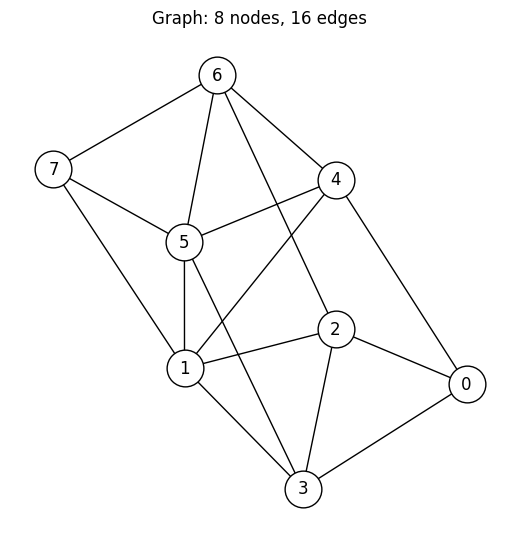

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

num_nodes = 8
edge_list = [
    [0, 2],
    [0, 3],
    [0, 4],
    [1, 2],
    [1, 3],
    [1, 4],
    [1, 5],
    [1, 7],
    [2, 3],
    [2, 6],
    [3, 5],
    [4, 5],
    [4, 6],
    [5, 6],
    [5, 7],
    [6, 7],
]

G = nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(edge_list)

pos = nx.spring_layout(G, seed=1)
plt.figure(figsize=(5, 5))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
plt.show()

## Create the Instance

We extract the edge list from the graph and evaluate the JijModeling
problem with the concrete data.

In [4]:
num_colors = 3
instance_data = {"N": num_nodes, "E": edge_list, "K": num_colors}
instance = graph_coloring_decorated.eval(instance_data)

## Set Up the AOAConverter

`AOAConverter` takes an OMMX instance and internally convert it into a QUBO form and build the Hamiltonian (see QAOA tutorial for more details).

Recall:
1. The energy values from the decoded samples are **not** the original objective, it includes **penalty terms**.
2. We need to re-evaluate the true objective values separately

In [5]:
from qamomile.optimization.aoa import AOAConverter

converter = AOAConverter(instance)
converter.spin_model = converter.spin_model.normalize_by_abs_max()
hamiltonian = converter.get_cost_hamiltonian()
print(hamiltonian)

Hamiltonian((Z0,): -0.7142857142857143, (Z1,): -0.7142857142857143, (Z2,): -0.7142857142857143, (Z6,): -0.8571428571428571, (Z9,): -0.8571428571428571, (Z12,): -0.8571428571428571, (Z7,): -0.8571428571428571, (Z10,): -0.8571428571428571, (Z13,): -0.8571428571428571, (Z8,): -0.8571428571428571, (Z11,): -0.8571428571428571, (Z14,): -0.8571428571428571, (Z3,): -1.0, (Z4,): -1.0, (Z5,): -1.0, (Z15,): -1.0, (Z21,): -0.7142857142857143, (Z16,): -1.0, (Z22,): -0.7142857142857143, (Z17,): -1.0, (Z23,): -0.7142857142857143, (Z18,): -0.8571428571428571, (Z19,): -0.8571428571428571, (Z20,): -0.8571428571428571, (Z0, Z1): 0.2857142857142857, (Z0, Z2): 0.2857142857142857, (Z0, Z6): 0.14285714285714285, (Z0, Z9): 0.14285714285714285, (Z0, Z12): 0.14285714285714285, (Z1, Z2): 0.2857142857142857, (Z1, Z7): 0.14285714285714285, (Z1, Z10): 0.14285714285714285, (Z1, Z13): 0.14285714285714285, (Z2, Z8): 0.14285714285714285, (Z2, Z11): 0.14285714285714285, (Z2, Z14): 0.14285714285714285, (Z3, Z4): 0.285714

## Transpile to an Executable Circuit

`converter.transpile()` works exactly as in the QAOA case.

In addition, we can select what kind of XY mixer and initial state we want to use.
For initial state, we can choose between 
- `single_basis_state` : to start from a single computational basis state
- `dicke`: to start from a superposition state having the same Hamming weight (number of ones)
- `uniform` : to start from an equal superposition of all basis states (as in QAOA)

For mixer, we can select
- `ring` : implement a ring XY mixer with a single level of connectivity
- `fully-connected` : implement a fully-connected XY mixer 

In [6]:
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()
p = 5  # number of AOA layers

executable_aoa_dicke = converter.transpile(
    transpiler,
    p=p,
    initial_state="dicke",
    hamming_weight=1,
    mixer="fully-connected",
    block_size=num_colors,
)

In [11]:
from qamomile.circuit.algorithm import aoa_state_dicke

initial_ones,pair_indices_dicke,triplets_indices_dicke,pair_angles_dicke,triplets_angles_dicke=converter._compute_dicke_composition_schedule(hamming_weight=1, block_size=num_colors)
resolved_pair = converter._resolve_pair_indices(mixer="fully-connected", pair_indices=None, block_size=num_colors)
gammas_draw = [1]
betas_draw = [1]

fig = aoa_state_dicke.draw(
    p=1,
    quad=converter.spin_model.quad,
    linear=converter.spin_model.linear,
    n=converter.spin_model.num_bits,
    gammas=gammas_draw,
    betas=betas_draw,
    pair_indices_mixer=resolved_pair,
    initial_ones=initial_ones,
    pair_indices_dicke=pair_indices_dicke,
    triplets_indices_dicke=triplets_indices_dicke,
    pair_angles_dicke=pair_angles_dicke,
    triplets_angles_dicke=triplets_angles_dicke,
    expand_composite=True,
    inline=True,
    fold_loops=False,
    inline_depth=10,
)
fig

In [10]:
transpiler_draw = QiskitTranspiler()
circuit_draw = converter.transpile(
    transpiler_draw,
    p=1,
    initial_state="dicke",
    hamming_weight=1,
    mixer="fully-connected",
    block_size=num_colors,
)
circuit_draw.quantum_circuit.draw('mpl', fold=-1)
